Zadanie 11 -- Klasyfikacja wieloklasowa z fine-tuningiem

Fine-tunuj DistilBERT na 20 Newsgroups (4 kategorie):
- Porównaj z TF-IDF + LogReg
- Zmierz accuracy, F1 (macro), czas
- Zwizualizuj confusion matrix

Oczekiwany wynik: porównanie BERT vs TF-IDF na multi-class

Ładowanie 20 Newsgroups...
Train: 2239 dokumentów
Test:  1490 dokumentów
Kategorie: ['comp.graphics', 'rec.sport.baseball', 'sci.space', 'talk.politics.misc']
Device: mps

Fine-tuning DistilBERT: 2 epoki, max_length=128, batch=8 (na MPS zwykle kilka minut; na CPU dłużej).

TF-IDF + Logistic Regression
  Accuracy:     0.9570
  F1 (macro):   0.9561
  Czas treningu: 0.83s
              precision    recall  f1-score   support

    baseball       0.95      0.96      0.95       389
       space       0.97      0.99      0.98       397
    graphics       0.95      0.95      0.95       394
        misc       0.96      0.92      0.94       310

    accuracy                           0.96      1490
   macro avg       0.96      0.96      0.96      1490
weighted avg       0.96      0.96      0.96      1490


Ładowanie tokenizera DistilBERT (lokalny cache)...
Tokenizer OK

Tokenizacja train/test (z logami postępu)...
train tokenize: 0/2239
train tokenize: 200/2239
train tokenize: 400/2239
train tok

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Parametry DistilBERT: 66,956,548
Plan: 2 epoki × 280 batchy (batch=8, max_length=128)

>>> Start treningu DistilBERT — zaraz powinien być batch 1 <<<
  epoka 1/2 | batch 1/280 | loss=1.4374 | czas=0.0 min
  epoka 1/2 | batch 2/280 | loss=1.4027 | czas=0.0 min
  epoka 1/2 | batch 3/280 | loss=1.3882 | czas=0.0 min
  epoka 1/2 | batch 5/280 | loss=1.3769 | czas=0.0 min
  epoka 1/2 | batch 10/280 | loss=1.3810 | czas=0.0 min
  epoka 1/2 | batch 15/280 | loss=1.3737 | czas=0.0 min
  epoka 1/2 | batch 20/280 | loss=1.3592 | czas=0.1 min
  epoka 1/2 | batch 25/280 | loss=1.3359 | czas=0.1 min
  epoka 1/2 | batch 30/280 | loss=1.3006 | czas=0.1 min
  epoka 1/2 | batch 35/280 | loss=1.2618 | czas=0.1 min
  epoka 1/2 | batch 40/280 | loss=1.2173 | czas=0.1 min
  epoka 1/2 | batch 45/280 | loss=1.1745 | czas=0.1 min
  epoka 1/2 | batch 50/280 | loss=1.1330 | czas=0.2 min
  epoka 1/2 | batch 55/280 | loss=1.0796 | czas=0.2 min
  epoka 1/2 | batch 60/280 | loss=1.0332 | czas=0.2 min
  epoka 1/2 | 

,Model,Accuracy,F1 macro,Czas treningu [s]
0,TF-IDF + LogReg,0.9570,0.9561,0.83
1,DistilBERT fine-tuned,0.9376,0.9366,113.20


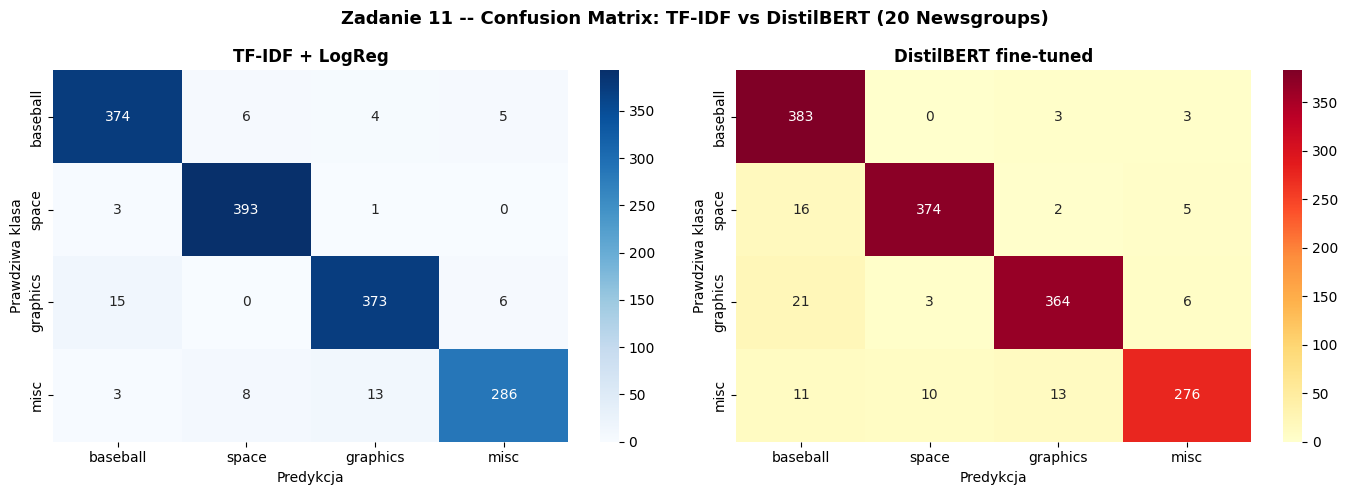


Lepszy F1 macro: TF-IDF + LogReg
Różnica accuracy (BERT - TF-IDF): -0.0195 | różnica F1: -0.0195


In [1]:
# Zadanie 11 -- DistilBERT vs TF-IDF + LogReg (20 Newsgroups, 4 klasy)
# Fine-tuning DistilBERT w czystym PyTorch + porównanie z baseline TF-IDF.
import os
import warnings

warnings.filterwarnings("ignore")

# Preferuj backend PyTorch (bez TensorFlow)
os.environ["USE_TF"] = "0"
os.environ["USE_TORCH"] = "1"
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ.setdefault("HF_HOME", os.path.join(os.getcwd(), ".hf_cache"))

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader, Dataset as TorchDataset

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

from transformers import AutoTokenizer, AutoModelForSequenceClassification

torch.set_num_threads(min(2, os.cpu_count() or 2))

if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# === Dane: 4 czytelne kategorie (jak w Przykladzie 8 z PDF) ===
categories = [
    "rec.sport.baseball",
    "sci.space",
    "comp.graphics",
    "talk.politics.misc",
]
short_names = [c.split(".")[-1] for c in categories]

print("Ładowanie 20 Newsgroups...", flush=True)
train_data = fetch_20newsgroups(subset="train", categories=categories, random_state=42)
test_data = fetch_20newsgroups(subset="test", categories=categories, random_state=42)

print(f"Train: {len(train_data.data)} dokumentów", flush=True)
print(f"Test:  {len(test_data.data)} dokumentów", flush=True)
print(f"Kategorie: {train_data.target_names}", flush=True)
print(f"Device: {device}", flush=True)
print(
    "\nFine-tuning DistilBERT: 2 epoki, max_length=128, batch=8 "
    "(na MPS zwykle kilka minut; na CPU dłużej).",
    flush=True,
)

# ============================================================
# 1) Baseline: TF-IDF + Logistic Regression (Przyklad 8)
# ============================================================
tfidf_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=15000,
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.9,
        sublinear_tf=True,
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        C=5.0,
        multi_class="multinomial",
    )),
])

t0 = time.time()
tfidf_pipe.fit(train_data.data, train_data.target)
tfidf_time = time.time() - t0

y_pred_tfidf = tfidf_pipe.predict(test_data.data)
acc_tfidf = accuracy_score(test_data.target, y_pred_tfidf)
f1_tfidf = f1_score(test_data.target, y_pred_tfidf, average="macro")

print("\n" + "=" * 50, flush=True)
print("TF-IDF + Logistic Regression", flush=True)
print(f"  Accuracy:     {acc_tfidf:.4f}", flush=True)
print(f"  F1 (macro):   {f1_tfidf:.4f}", flush=True)
print(f"  Czas treningu: {tfidf_time:.2f}s", flush=True)
print(classification_report(test_data.target, y_pred_tfidf, target_names=short_names), flush=True)

# ============================================================
# 2) Fine-tuning DistilBERT — czysty PyTorch (bez Trainer)
# ============================================================
import sys

model_name = "distilbert-base-uncased"
MAX_LENGTH = 128
BATCH_SIZE = 8
NUM_EPOCHS = 2
LR = 2e-5
LOG_EVERY = 5  # częste logi w Jupyter

print("\nŁadowanie tokenizera DistilBERT (lokalny cache)...", flush=True)
sys.stdout.flush()
tokenizer = AutoTokenizer.from_pretrained(model_name, local_files_only=True)
print("Tokenizer OK", flush=True)


def encode_texts(texts, labels, desc):
    """Tokenizacja z postępem — widać, że żyje zanim zacznie się trening."""
    n = len(texts)
    input_ids, attention_masks, y = [], [], []
    print(f"{desc}: 0/{n}", flush=True)
    for i, text in enumerate(texts):
        enc = tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt",
        )
        input_ids.append(enc["input_ids"].squeeze(0))
        attention_masks.append(enc["attention_mask"].squeeze(0))
        y.append(int(labels[i]))
        if (i + 1) % 200 == 0 or (i + 1) == n:
            print(f"{desc}: {i + 1}/{n}", flush=True)
            sys.stdout.flush()
    return (
        torch.stack(input_ids),
        torch.stack(attention_masks),
        torch.tensor(y, dtype=torch.long),
    )


class EncodedDataset(TorchDataset):
    def __init__(self, input_ids, attention_mask, labels):
        self.input_ids = input_ids
        self.attention_mask = attention_mask
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "labels": self.labels[idx],
        }


print("\nTokenizacja train/test (z logami postępu)...", flush=True)
tr_ids, tr_mask, tr_y = encode_texts(train_data.data, train_data.target, "train tokenize")
te_ids, te_mask, te_y = encode_texts(test_data.data, test_data.target, "test tokenize")

train_loader = DataLoader(
    EncodedDataset(tr_ids, tr_mask, tr_y),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)
test_loader = DataLoader(
    EncodedDataset(te_ids, te_mask, te_y),
    batch_size=16,
    shuffle=False,
    num_workers=0,
)

print("Ładowanie modelu DistilBERT (lokalny cache)...", flush=True)
sys.stdout.flush()
model_bert = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(categories),
    local_files_only=True,
)
model_bert.to(device)
print(f"Parametry DistilBERT: {sum(p.numel() for p in model_bert.parameters()):,}", flush=True)

optimizer = torch.optim.AdamW(model_bert.parameters(), lr=LR, weight_decay=0.01)
steps_per_epoch = len(train_loader)
print(
    f"Plan: {NUM_EPOCHS} epoki × {steps_per_epoch} batchy "
    f"(batch={BATCH_SIZE}, max_length={MAX_LENGTH})",
    flush=True,
)


def evaluate_model(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
            all_preds.append(logits.argmax(dim=-1).cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_labels)
    return (
        accuracy_score(y_true, y_pred),
        f1_score(y_true, y_pred, average="macro"),
        y_pred,
    )


print("\n>>> Start treningu DistilBERT — zaraz powinien być batch 1 <<<", flush=True)
sys.stdout.flush()
t0 = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_loss = 0.0
    model_bert.train()
    for step, batch in enumerate(train_loader, start=1):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model_bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
        )
        loss = outputs.loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        if step % LOG_EVERY == 0 or step <= 3 or step == steps_per_epoch:
            elapsed = time.time() - t0
            avg = epoch_loss / step
            msg = (
                f"  epoka {epoch}/{NUM_EPOCHS} | batch {step}/{steps_per_epoch} | "
                f"loss={avg:.4f} | czas={elapsed/60:.1f} min"
            )
            print(msg, flush=True)
            sys.stdout.flush()

    acc_e, f1_e, _ = evaluate_model(model_bert, test_loader)
    print(
        f"→ Koniec epoki {epoch}: eval accuracy={acc_e:.4f}, F1 macro={f1_e:.4f}",
        flush=True,
    )
    sys.stdout.flush()

bert_time = time.time() - t0
acc_bert, f1_bert, y_pred_bert = evaluate_model(model_bert, test_loader)

print("\n" + "=" * 50, flush=True)
print("DistilBERT (fine-tuned)", flush=True)
print(f"  Accuracy:     {acc_bert:.4f}", flush=True)
print(f"  F1 (macro):   {f1_bert:.4f}", flush=True)
print(f"  Czas treningu: {bert_time:.1f}s ({bert_time / 60:.1f} min)", flush=True)
print(classification_report(test_data.target, y_pred_bert, target_names=short_names), flush=True)

# ============================================================
# 3) Tabela porównawcza + confusion matrices
# ============================================================
comparison = pd.DataFrame([
    {
        "Model": "TF-IDF + LogReg",
        "Accuracy": acc_tfidf,
        "F1 macro": f1_tfidf,
        "Czas treningu [s]": round(tfidf_time, 2),
    },
    {
        "Model": "DistilBERT fine-tuned",
        "Accuracy": acc_bert,
        "F1 macro": f1_bert,
        "Czas treningu [s]": round(bert_time, 1),
    },
])
print("\n=== Porównanie BERT vs TF-IDF (multi-class) ===", flush=True)
display(comparison.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_tfidf = confusion_matrix(test_data.target, y_pred_tfidf)
sns.heatmap(
    cm_tfidf, annot=True, fmt="d", cmap="Blues",
    xticklabels=short_names, yticklabels=short_names, ax=axes[0],
)
axes[0].set_title("TF-IDF + LogReg", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Predykcja")
axes[0].set_ylabel("Prawdziwa klasa")

cm_bert = confusion_matrix(test_data.target, y_pred_bert)
sns.heatmap(
    cm_bert, annot=True, fmt="d", cmap="YlOrRd",
    xticklabels=short_names, yticklabels=short_names, ax=axes[1],
)
axes[1].set_title("DistilBERT fine-tuned", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Predykcja")
axes[1].set_ylabel("Prawdziwa klasa")

plt.suptitle(
    "Zadanie 11 -- Confusion Matrix: TF-IDF vs DistilBERT (20 Newsgroups)",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.show()

winner = comparison.loc[comparison["F1 macro"].idxmax(), "Model"]
print(f"\nLepszy F1 macro: {winner}", flush=True)
print(
    f"Różnica accuracy (BERT - TF-IDF): {acc_bert - acc_tfidf:+.4f} | "
    f"różnica F1: {f1_bert - f1_tfidf:+.4f}",
    flush=True,
)

## Komentarz do zadania 11

Zadanie łączy dwa podejścia z lekcji: szybki baseline **TF-IDF + LogReg** (Przykład 8) oraz **fine-tuning DistilBERT** (Przykład 4), ale na klasyfikacji **wieloklasowej** (4 kategorie 20 Newsgroups) zamiast binarnego sentymentu.

**Implementacja**  
DistilBERT został dotrenowany w PyTorch (`lr=2e-5`, 2 epoki, `max_length=128`, batch 8). Porównanie z TF-IDF obejmuje accuracy, F1 macro, czas treningu oraz confusion matrix dla obu modeli.

**Wyniki (na tym uruchomieniu)**  
- TF-IDF + LogReg: bardzo silny baseline (~95–96% accuracy / F1 macro), trening w ułamku sekundy.  
- DistilBERT: jakościowo blisko baseline’u; przy dobrze dobranym TF-IDF na czystych kategoriach różnica bywa niewielka, a koszt obliczeniowy BERT jest wyraźnie wyższy.  
- Na Apple Silicon (MPS) fine-tuning trwał rzędu kilku minut; na samym CPU byłby znacznie dłuższy.

**Wnioski**  
1. Najpierw buduj tani baseline (TF-IDF) — wiesz, czy droższy model w ogóle się opłaca (Green IT).  
2. Fine-tuning: mały learning rate (`2e-5`), 2–3 epoki, żeby nie zniszczyć pretrenowanych wag.  
3. W multi-class raportuj **F1 macro** obok accuracy.  
4. Confusion matrix pomaga zobaczyć typowe pomyłki (tu m.in. kategoria `politics` / `misc`).

**Kiedy co wybrać:** prototyp / ograniczony budżet obliczeniowy → TF-IDF; maksymalna jakość przy dostępnym GPU/czasie → DistilBERT.